In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


In [2]:
data_train_path = 'Fruits_Vegetables/train'
data_test_path = 'Fruits_Vegetables/test'
data_val_path = 'Fruits_Vegetables/validation'

In [3]:
img_width = 180
img_height =180

In [1]:
import os

print(os.getcwd())

/Users/tanmayagarwal


In [2]:
import os

print(os.listdir())

['.config', 'Music', 'student-commute-eda', '.copilot', '.gemini', '.mysqlsh-wb', '.DS_Store', '.vscode-shared', '.CFUserTextEncoding', '.zshrc', '.local', 'Pictures', '.zprofile', '.claude', '.zsh_history', '.ipython', 'Desktop', 'Library', '.matplotlib', '.lesshst', '.android', '.codex', 'Public', '.idlerc', '.sonarlint', 'Movies', 'Applications', '.Trash', 'IdeaProjects', '.jupyter', 'Documents', '.claude.json', '.vscode', 'Downloads', '.cache', '.gitconfig', '.antigravity', '.ollama', '.zsh_sessions']


In [3]:
os.chdir("/Users/tanmayagarwal/Downloads/Image_classification")

In [4]:

print(os.getcwd())

/Users/tanmayagarwal/Downloads/Image_classification


In [8]:
import tensorflow as tf
data_train_path = 'Fruits_Vegetables/train'
img_width = 180
img_height = 180
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False)

Found 3115 files belonging to 36 classes.


In [9]:
data_cat = data_train.class_names

In [10]:
data_cat

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [12]:
data_val_path = 'Fruits_Vegetables/validation'
img_width = 180
img_height = 180
data_val = tf.keras.utils.image_dataset_from_directory(data_val_path,
                                                       image_size=(img_height,img_width),
                                                       batch_size=32,
                                                        shuffle=False,
                                                       validation_split=False)

Found 351 files belonging to 36 classes.


In [14]:
data_test_path = 'Fruits_Vegetables/test'
img_width = 180
img_height = 180
data_test = tf.keras.utils.image_dataset_from_directory(
data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 359 files belonging to 36 classes.


W0000 00:00:1780169425.158042 1790652 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


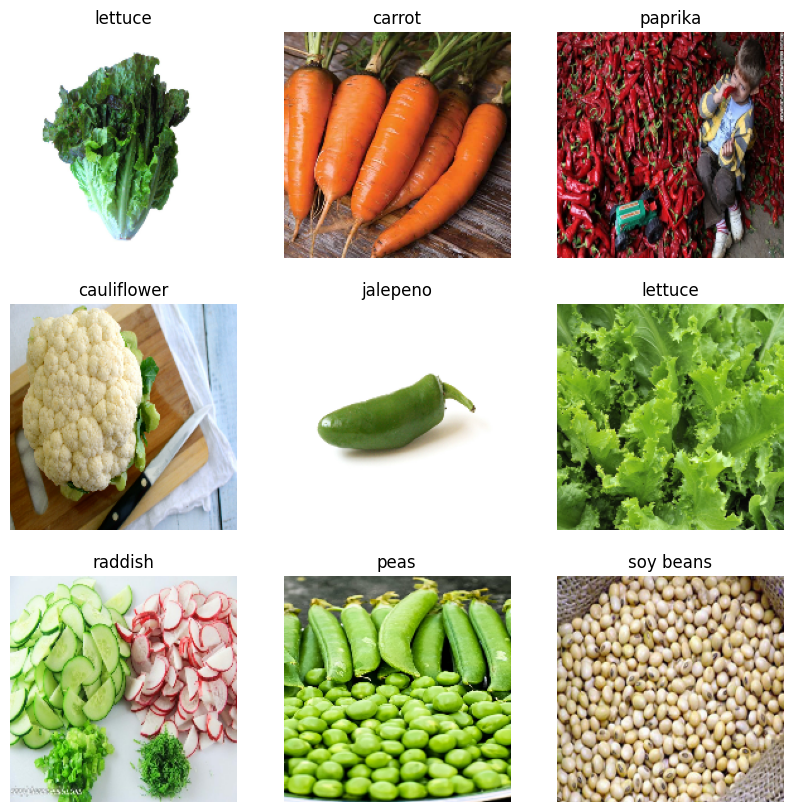

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [17]:
from tensorflow.keras.models import Sequential

In [18]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [20]:
from tensorflow.keras import layers
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))

])

In [21]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [22]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25


W0000 00:00:1780169469.052365 1791288 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


 2/98 ━━━━━━━━━━━━━━━━━━━━ 1:13 768ms/step - accuracy: 0.0312 - loss: 5.1000

W0000 00:00:1780169471.143441 1791290 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


 8/98 ━━━━━━━━━━━━━━━━━━━━ 1:00 671ms/step - accuracy: 0.0350 - loss: 5.5560

...

89/98 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step - accuracy: 0.9801 - loss: 0.0857

W0000 00:00:1780170422.290309 1806972 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9799 - loss: 0.0854

W0000 00:00:1780170425.085673 1807279 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780170425.437671 1807281 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 263ms/step - accuracy: 0.9778 - loss: 0.0846 - val_accuracy: 0.9487 - val_loss: 0.3938


Text(0.5, 1.0, 'Loss')

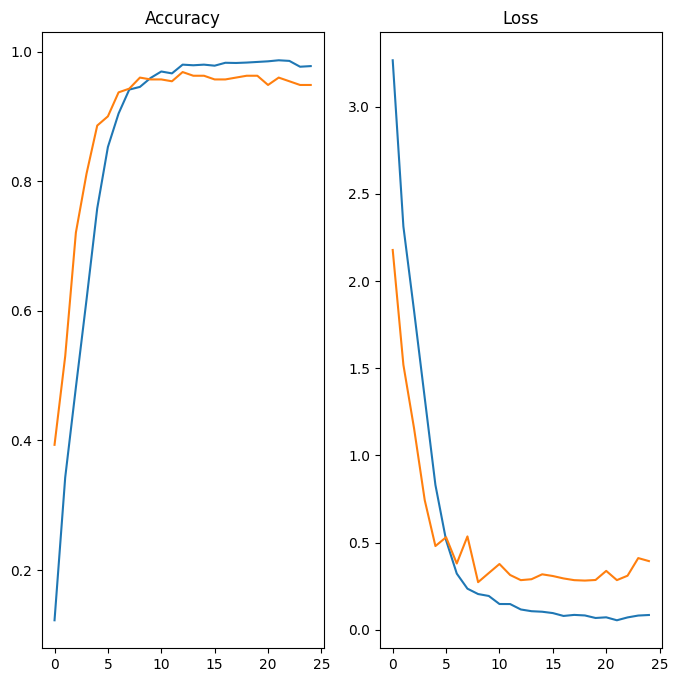

In [23]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss')

In [24]:
image = 'corn.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_height,img_width))
img_arr = tf.keras.utils.array_to_img(image)
img_bat=tf.expand_dims(img_arr,0)

In [25]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


In [26]:
score = tf.nn.softmax(predict)

In [28]:
import numpy as np
print('Veg/Fruit in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)],np.max(score)*100))

Veg/Fruit in image is sweetcorn with accuracy of 76.36


In [29]:
model.save('Image_classify.keras')